#  Computation of BOP Features

- input: atoms objects
- output here: all the descriptors comming from BOP (averages, atomic site based, etc)

#  Calculation of features from available libraries

- input curated BS

# TODO
- [X] Calculate site specific averages
- [ ] Distributions of descriptors / characterization of descriptors

In [1]:
import os
import sys
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer import Featurizer, BopfoxFeatures
import pandas as pd

## options:

In [4]:
dataset = 'Fe-Mo'
atomsobjectloc = os.path.join(dataset, 'Atomsobjects')
components = dataset.replace('-','')
models = ['canonical','projections', 'projections_os']
cutoff = 'table'
atoms = 'initial'
moments = 16

In [5]:
# only loop over the models
atomspickle =  os.path.join(atomsobjectloc, f'{components}-POSCAR-{atoms}-rescaled-AtomsObjects.pkl')
AtomsObjects = pd.read_pickle(atomspickle).dropna(how='any')

In [9]:
results = {}
resultspickle = {}
for model in models:
    modelsfile = os.path.join('models', f'{components}_{model}.bx')
    print('atoms: ', atoms, 'model: ', model, '  cutoff: ', cutoff, ' moments:', moments)
    resultspickle[model] = os.path.join(dataset, 'Descriptors', f'{components}_{atoms}_{model}_{cutoff}_WUBIND_{moments}.pkl')
    BOPC = BopfoxFeatures(
            AtomsObjects['atoms'],modelsfile, modelname=model,
            cutoffby=cutoff, 
            binary = '/home/storage/fortimtb/CuadernoTrabajo/oldrepobopfox/src/bopfox_mpi',
            moments = moments
            )
    BOPC.calculate_bop_forall(ForceKeepSpecies=True,
            input_pickle = resultspickle[model]
            )
    results[model] = BOPC.RESULTS

atoms:  initial model:  canonical   cutoff:  table  moments: 16


  0%|          | 0/289 [00:00<?, ?it/s] 

atoms:  initial model:  projections   cutoff:  table  moments: 16


  0%|          | 0/289 [00:00<?, ?it/s] 

atoms:  initial model:  projections_os   cutoff:  table  moments: 16


  0%|          | 0/289 [00:00<?, ?it/s] 

# Failed BOP Calculations 

In [10]:
for model, result in results.items():
    print(f'{model} model:')
    print(result.isna().sum())
    print(result[result.isna().any(axis=1)])
    print('=================')

canonical model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections_os model:
U_bind               0
U_bond_atom          0
U_bond_atom_list     0
moments             21
normed_moments       0
an                   0
bn                   0
sigma                0
Ainf                 0
Binf           

##  remove bad data

In [11]:
removenans = [result.dropna(inplace=True) for model, result in results.items()]

In [12]:
for model, result in results.items():
    print(f'{model} model:')
    print(result.isna().sum())
    print(result[result.isna().any(axis=1)])
    print('=================')

canonical model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections_os model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dt

In [13]:
for (model, resultpckl), result in zip(resultspickle.items(), results.values()):
    result.to_pickle(resultpckl)

# Arrangement and averaging BOP Features 

In [16]:
descriptorlocation = os.path.join(dataset, 'Descriptors' )

In [17]:
CNListLocation = os.path.join(descriptorlocation,'CNList.pkl')

In [21]:
CNList = pd.read_pickle(CNListLocation)

In [22]:
from Tools.DatasetTools import GeneralFeaturizer as gf

In [24]:
#PyscalFeaturesFile = os.path.join(descriptorlocation, 'pyscal_steinhardt.kpl')

In [25]:
#PyscalFeatures = pd.read_pickle(PyscalFeaturesFile)

In [27]:
resultscnav = {}
specialcolumns =['U_bind','U_bond_atom', 'U_bond_atom_list'] 
for model, result in results.items():
    columnstoexpand = result.columns.drop(specialcolumns)
    df = gf.array_expansions(result, columnstoexpand)
    ThisCoordination = CNList[result.index]
    resultscnav[model] = gf.featurize_dataframe(df, ThisCoordination)
    resultscnav[model] = pd.concat([result[specialcolumns[:-1]], resultscnav[model]],  axis=1)
    averaged_bop_file = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(resultspickle[model]))
    resultscnav[model].to_pickle(averaged_bop_file)

In [28]:
resultscnav['canonical']

,U_bind,U_bond_atom,moments_1_0,moments_1_CN12,moments_1_CN13,moments_1_CN14,moments_1_CN15,moments_1_CN16,moments_2_0,moments_2_CN12,...,Ainf_1_CN13,Ainf_1_CN14,Ainf_1_CN15,Ainf_1_CN16,Binf_1_0,Binf_1_CN12,Binf_1_CN13,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16
Fe_pv8Mo_sv22.sigma-BBABB.FM,-100.702297,-120.454567,1.174563,0.433709,0.000000,0.617709,0.123145,0.000000,-0.305073,-0.112997,...,0.00000,-0.060960,-0.015284,0.000000,1.236738,0.411404,0.000000,0.660966,0.164368,0.000000
Fe_pv10Mo_sv20.sigma-ABBAB.FM,-78.594335,-118.926491,1.201761,0.443751,0.000000,0.632013,0.125997,0.000000,-0.315730,-0.116944,...,0.00000,-0.061662,-0.015460,0.000000,1.250974,0.416140,0.000000,0.668575,0.166260,0.000000
Fe_pv4Mo_sv20.C36-ABBBB.FM,-94.449166,-103.634999,1.303069,1.079142,0.000000,0.000000,0.000000,0.223928,-0.367340,-0.289155,...,0.00000,0.000000,0.000000,-0.076269,1.563349,1.061812,0.000000,0.000000,0.000000,0.501537
Fe_pv3Mo_sv10.mu-ABBBA.FM,-40.03529,-54.747798,1.265062,0.918735,0.000000,0.129279,0.091524,0.125524,-0.338961,-0.246156,...,0.00000,-0.030200,-0.038406,-0.027733,1.482176,0.814720,0.000000,0.220371,0.224323,0.222761
Fe_pv5Mo_sv24.chi-AABB.FM,-116.205661,-120.735035,1.162619,0.589668,0.434727,0.000000,0.000000,0.138224,-0.280823,-0.121560,...,-0.05443,0.000000,0.000000,-0.028074,1.160480,0.522949,0.451346,0.000000,0.000000,0.186186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,-40.03529,-54.747798,1.265062,0.918735,0.000000,0.129279,0.091524,0.125524,-0.338961,-0.246156,...,0.00000,-0.030200,-0.038406,-0.027733,1.482176,0.814720,0.000000,0.220371,0.224323,0.222761
Fe_pv8Mo_sv22.sigma-BBABB.NM,-100.702297,-120.454567,1.174563,0.433709,0.000000,0.617709,0.123145,0.000000,-0.305073,-0.112997,...,0.00000,-0.060960,-0.015284,0.000000,1.236738,0.411404,0.000000,0.660966,0.164368,0.000000
Fe_pv1Mo_sv3.L12-AB3.FM,-12.617373,-15.617373,1.063750,1.063750,0.000000,0.000000,0.000000,0.000000,-0.263148,-0.263148,...,0.00000,0.000000,0.000000,0.000000,1.191642,1.191642,0.000000,0.000000,0.000000,0.000000
Fe_pv8Mo_sv22.sigma-BBBBA.FM,-94.569986,-120.454567,1.174563,0.433709,0.000000,0.617709,0.123145,0.000000,-0.305073,-0.112997,...,0.00000,-0.060960,-0.015284,0.000000,1.236738,0.411404,0.000000,0.660966,0.164368,0.000000


# Characterization of BOP features 

In [29]:
import re

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize=(15,8))
plt.rc('font', size=22)

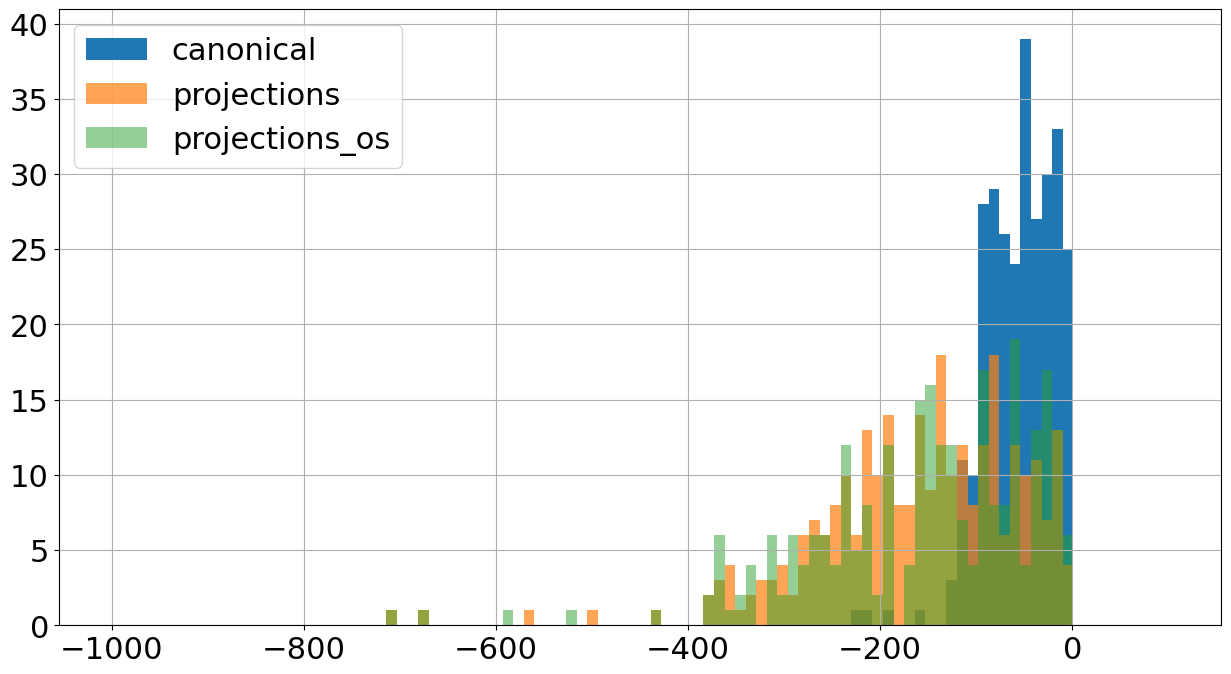

In [33]:
ax = resultscnav['canonical']['U_bind'].hist(bins=100, range=[-1000,100], label='canonical')
resultscnav['projections']['U_bind'].hist(bins=100, ax=ax, alpha=0.7, range=[-1000,100], label='projections')
resultscnav['projections_os']['U_bind'].hist(bins=100, ax=ax, alpha=0.5,range=[-1000,100], label='projections_os')
ax.legend()

In [34]:
def comparefeatures(featurename, featuresymbol):
    plotfeature = {f'{featurename}_{i}_0': fr'$\langle {featuresymbol}_{i} \rangle $' for i in range(1,4)}
    nplots = len(plotfeature)
    fig = plt.figure(figsize=(7*nplots, 5))
    ax = fig.subplots(1, nplots, sharey=True)
    ensamble = []
    for thisresultcnav, thisname in zip(resultscnav.values(), plotfeature.keys()):
        ensamble.append(thisresultcnav[thisname] )
    ensamble = pd.concat(ensamble, axis=0)
    thisrange = [ensamble.min(), ensamble.max()]
    for i, (feature, title) in enumerate(plotfeature.items()):
        ax[i].set_xlabel(title)
        for model, result in resultscnav.items():
            ax[i].hist(result[feature], density=True, bins=100, alpha=0.81, edgecolor='k', label=model, range=thisrange)
    ax[-1].legend()
    ax[0].set_ylabel('Counts')
    fig.tight_layout()

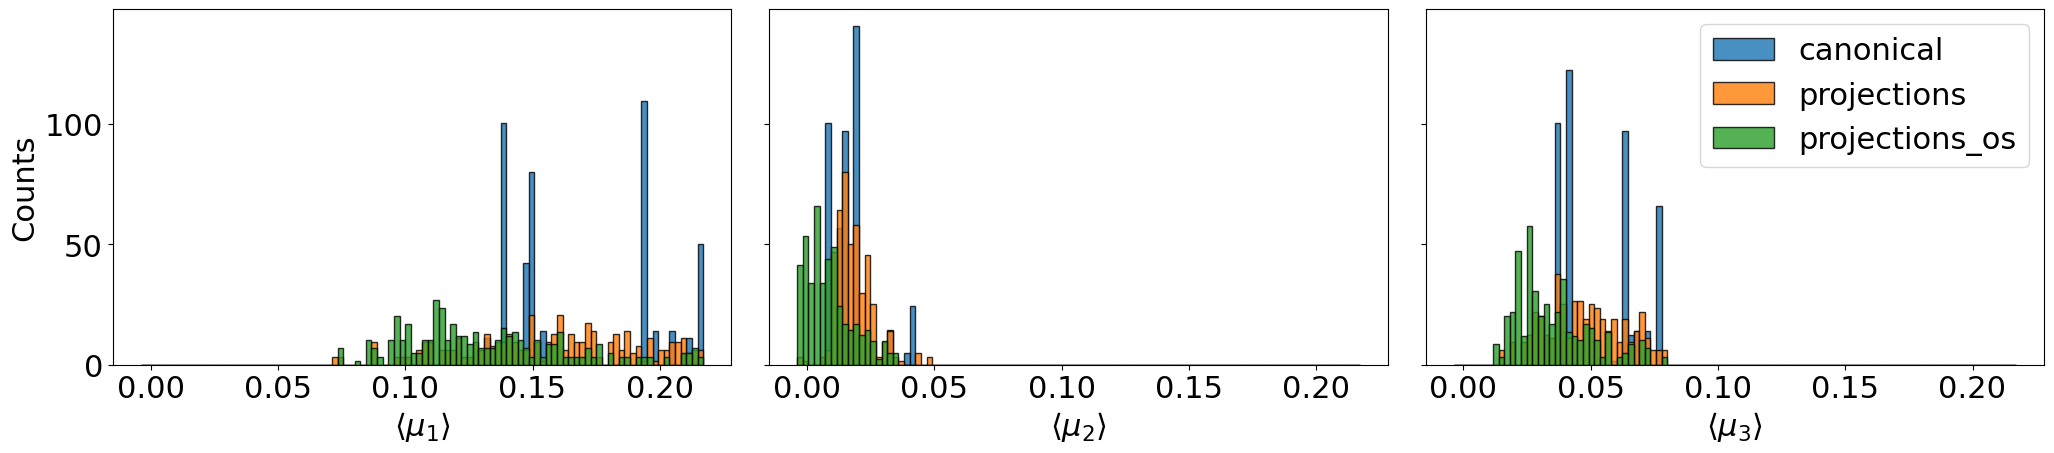

In [35]:
comparefeatures('normed_moments','\mu')

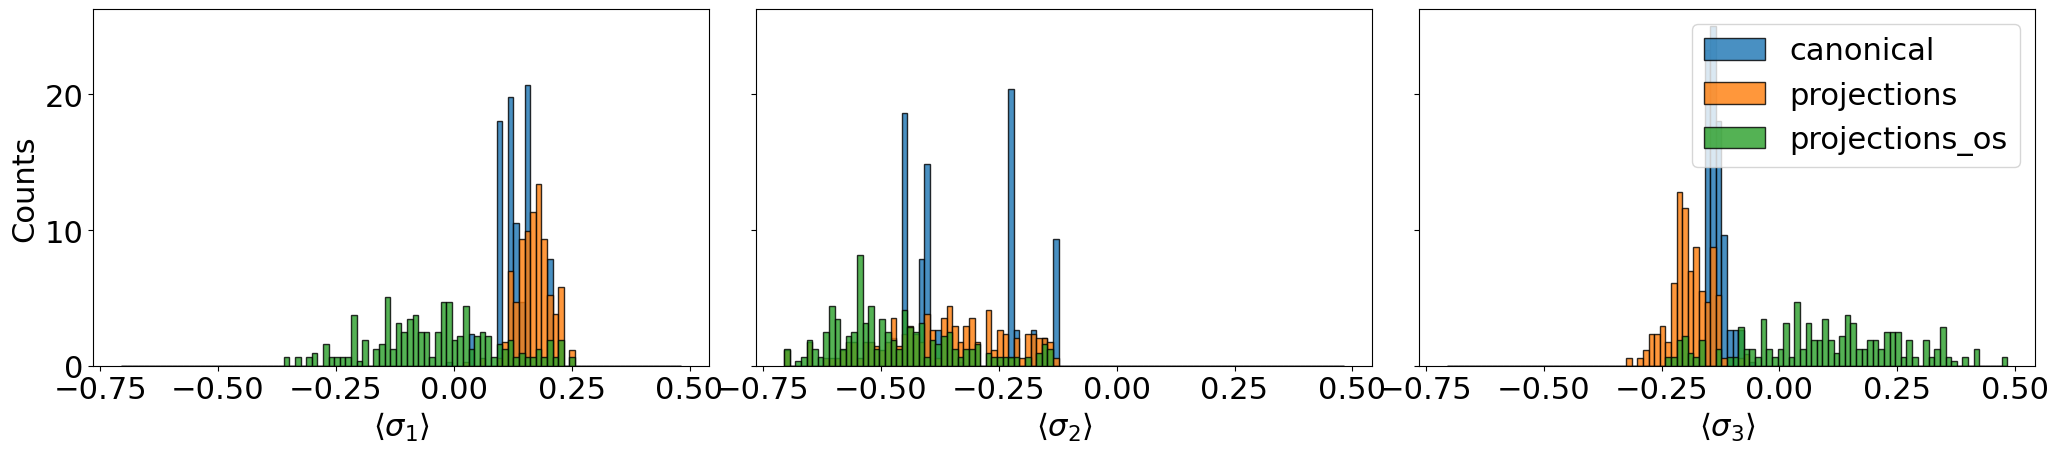

In [36]:
comparefeatures('sigma', '\sigma')

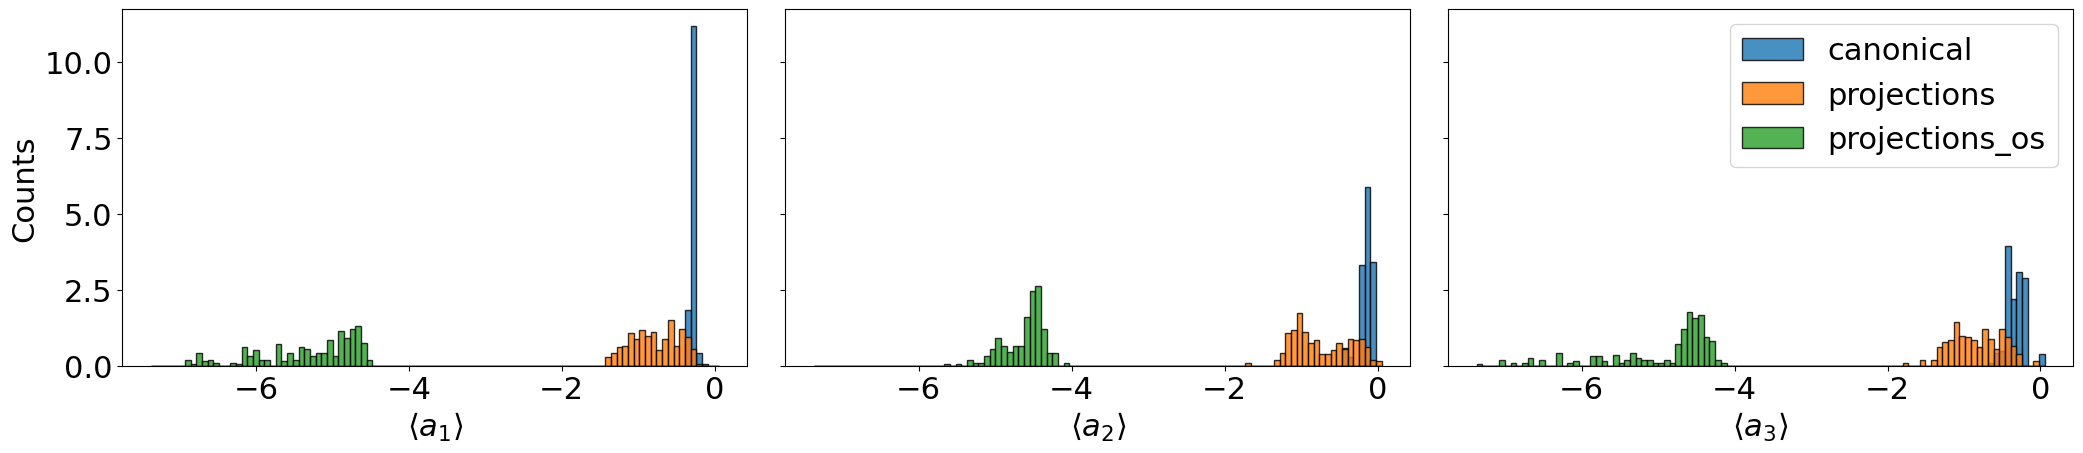

In [37]:
comparefeatures('an', 'a')

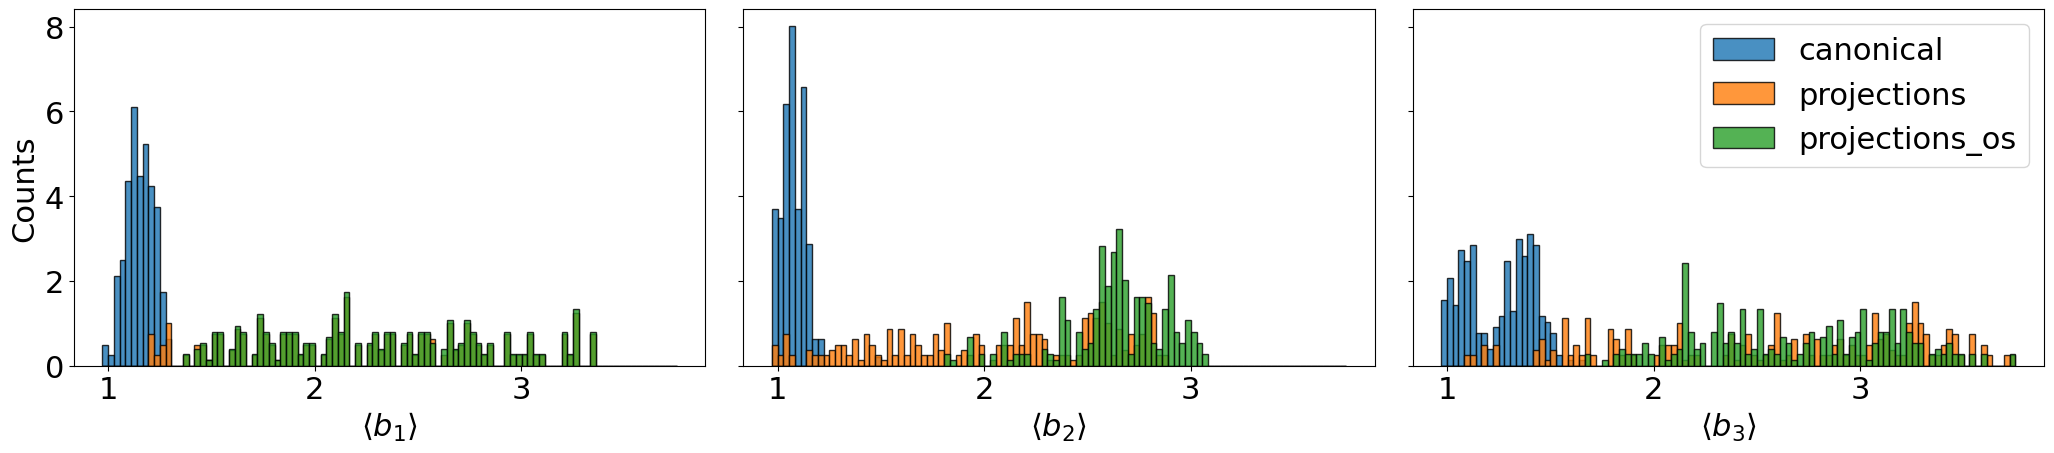

In [38]:
comparefeatures('bn', 'b')

In [39]:
CP = ['0', 'CN12', 'CN13', 'CN14','CN15','CN16']
CPSYMB=['_{0}',  '{CN_{12}}', '{CN_{13}}', '{CN_{14}}','{CN_{15}}','{CN_{16}}']

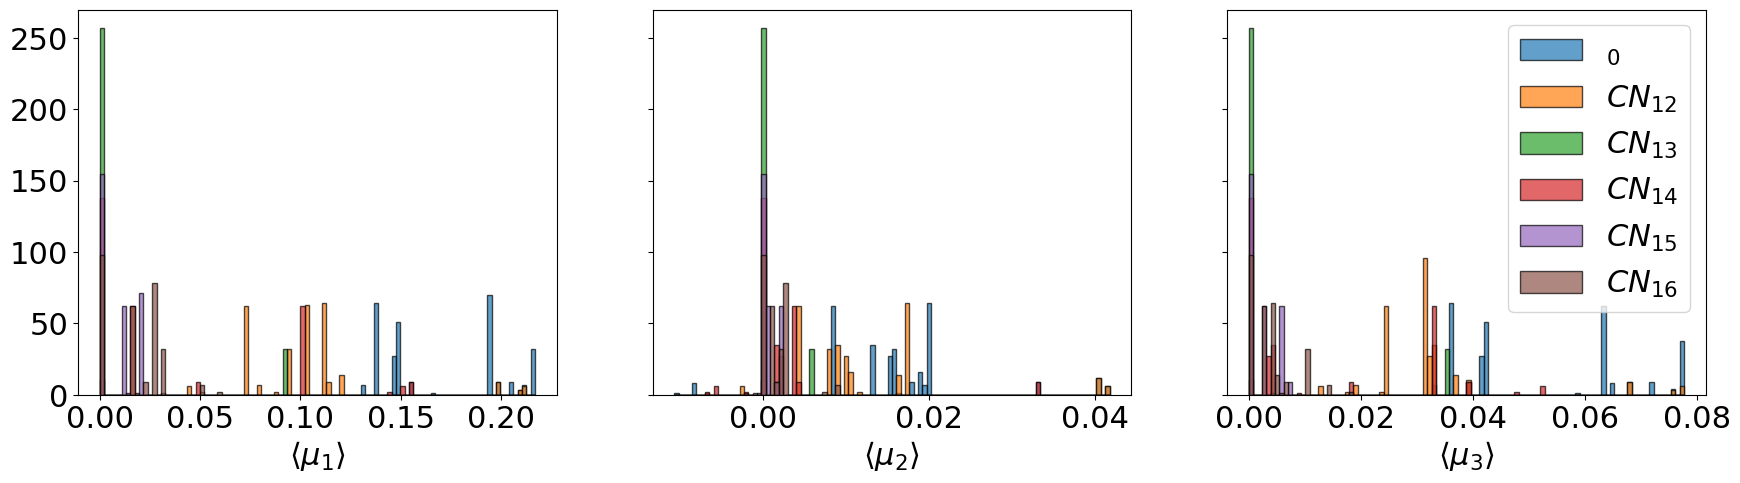

In [41]:
featurename = 'normed_moments'
featuresymbol = '\mu'
fig, ax = plt.subplots(1,3, figsize = (21,5), sharey=True)
for i, tax in enumerate(ax):
    for case, symbol in zip(CP,CPSYMB):
        featuremain = fr'{featurename}_{i+1}' 
        featurecol = fr'{featuremain}_{case}'
        featuretitle = fr'$\langle {featuresymbol}_{i+1} \rangle$'
        tax.set_xlabel(featuretitle)
        thismin = resultscnav['canonical'].filter(regex=featuremain+'_').min().min()
        thismaxn = resultscnav['canonical'].filter(regex=featuremain+'_').max().max()
    #     = fr'${featuresymbol}_{i} $' for i in range(1,4)}
        tax.hist(resultscnav['canonical'][f'{featurecol}'], label=f'${symbol}$',bins=100, edgecolor='k', alpha=0.7, range=[thismin, thismaxn])
ax[-1].legend()

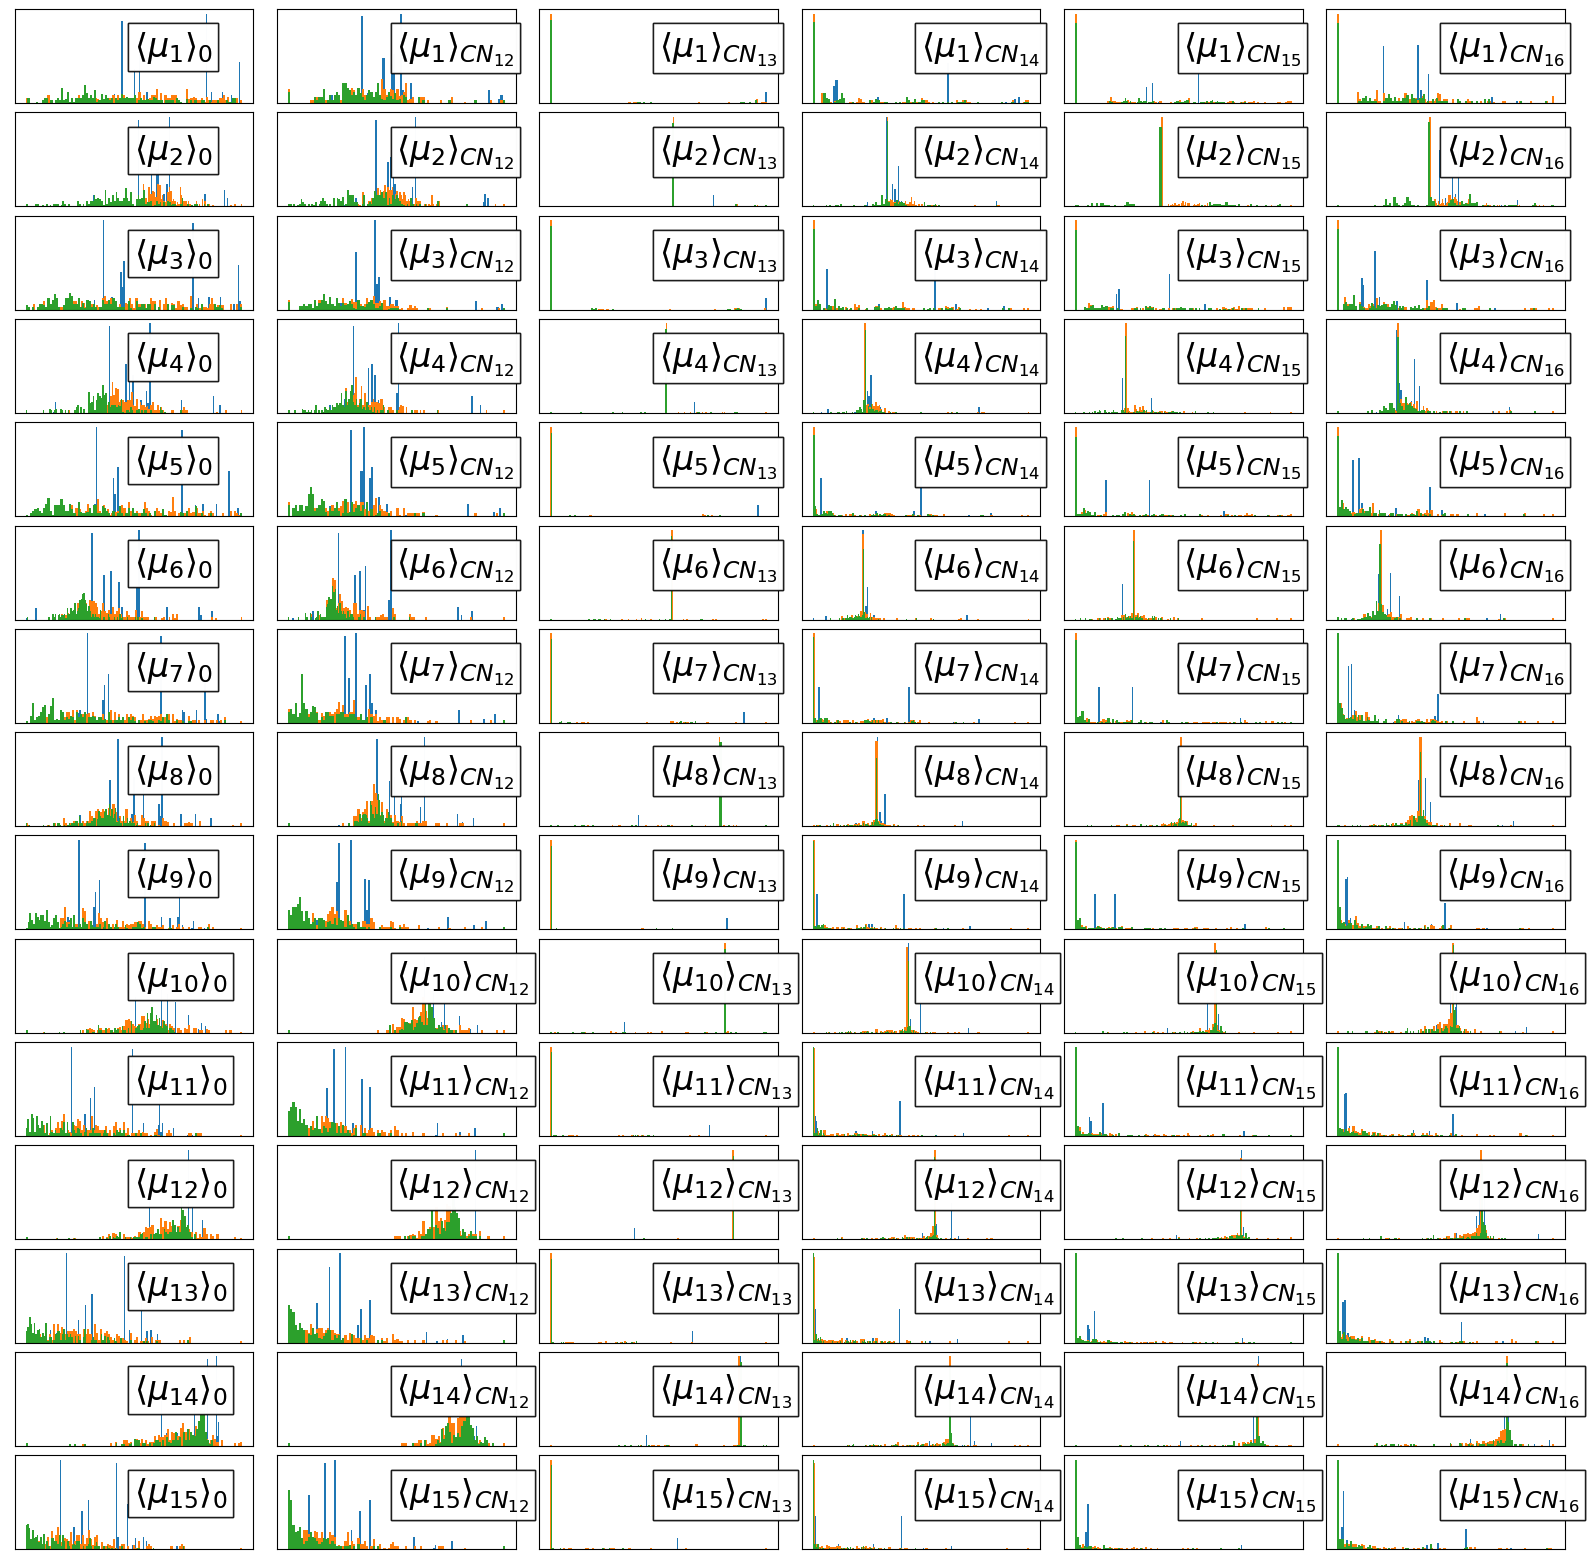

In [44]:
import Tools.DatasetTools.Tools as tl
plotter = tl.Plotting
selection = resultscnav['canonical'].columns.str.contains('normed_moments')
normedmomentnames = resultscnav['canonical'].columns[selection]
normedmomenttitles = pd.Series({name: re.sub('normed_moments_(.*)_',r'$\\langle \\mu_{\1} \\rangle ', name)+'$' for name in normedmomentnames})
normedmomenttitles = normedmomenttitles.map(lambda s: re.sub(' 0\$','_{0}$', s))
normedmomenttitles = normedmomenttitles.map(lambda s: re.sub(' CN(.*)\$','_{CN_{\\1}}$', s))
fig, ax = plotter.histoff_realfeatures(resultscnav['canonical'],normedmomentnames,normedmomenttitles,(20,20), ncols = 6)
fig, ax = plotter.histoff_realfeatures(resultscnav['projections'],normedmomentnames,normedmomenttitles,(20,20), ncols = 6, fig_ax=(fig, ax))
fig, ax = plotter.histoff_realfeatures(resultscnav['projections_os'],normedmomentnames,normedmomenttitles,(20,20), ncols = 6, fig_ax=(fig, ax))